# Logistic regression: the first trained model

**The question:** can a trained model predict next month's Up / Down / Flat direction for Zilretta's visit share better than the simple guesses and better than luck?

**The answer, in one line:** with the data we have, no. This notebook shows the evidence, including why, and what it means for the project. A clear negative result with the right checks behind it is a legitimate finding.

## What logistic regression is, in plain words

It looks at the 22 features for a month (recent share, last month's move, the calendar, and so on), gives each one a weight, adds them up, and turns the total into a probability for Up, Flat and Down. The model learns the weights from past months. Two settings matter here:

- **Regularization (the setting `C`).** A penalty that stops the weights from growing large, so the model can't memorize the quirks of the months it trained on. A *smaller* `C` means a *stronger* penalty. With only 24 to 58 training months and about 16 Up or Down months, memorizing is the main danger.
- **Class weights ("balanced").** Up and Down are rare. Balanced weights make a missed Down month cost more in training, because catching Down months is the priority.

Before training, the features are put on one scale (standardized). That step is learned from the training months only, inside each walk-forward step, so it can't see the future.

## Settings fixed in advance

To avoid fitting the 35 test months by accident, the primary model was fixed **before any result was seen**: standardized features, regularization `C = 0.1`, balanced class weights, all 22 features. Everything else in this notebook (other `C` values, other class weights, subsets of features) is **exploratory** and is reported in full, never used to pick a winner.

In [1]:
import sys
import warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

from oa_market_intelligence.features.monthly import (
    FEATURE_GROUPS, TARGET, compute_monthly_features, load_monthly_gold, model_ready_monthly)
from oa_market_intelligence.modeling.baselines import (
    MajorityClassBaseline, PersistenceBaseline, SeasonalBaseline, StratifiedRandomBaseline)
from oa_market_intelligence.modeling.evaluation import (
    CLASSES, DEFAULT_MIN_TRAIN, bootstrap_difference, bootstrap_scores, compare_models, confusion,
    in_sample_scores, mcnemar_exact, score_table, simulate_scores)
from oa_market_intelligence.modeling.models import PRIMARY_C, PRIMARY_CLASS_WEIGHT, make_logistic_regression

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

engine = create_engine("sqlite:///../data/processed/warehouse.db")
ready = model_ready_monthly(compute_monthly_features(load_monthly_gold(engine)))
FEATURES = list(ready.columns.drop(TARGET))
print(f"{len(ready)} model-ready months, {len(FEATURES)} features; primary model: C={PRIMARY_C}, class weights={PRIMARY_CLASS_WEIGHT}")

59 model-ready months, 22 features; primary model: C=0.1, class weights=balanced


## 1. The primary model against the baselines and chance

Same walk-forward test as before: train on the months up to *t*, predict month *t*, repeat. 24 months of initial training, then 35 test months (25 Flat, 6 Down, 4 Up).

In [2]:
MODELS = {"always-majority": MajorityClassBaseline, "persistence": PersistenceBaseline,
          "seasonal": SeasonalBaseline, "LOGISTIC (primary)": make_logistic_regression}
predictions = compare_models(ready, MODELS, min_train=DEFAULT_MIN_TRAIN)
cols = ["accuracy", "balanced_accuracy", "macro_f1", "precision_down", "recall_down", "recall_up", "recall_flat"]
scores = score_table(predictions)
scores[cols].round(3)

,accuracy,balanced_accuracy,macro_f1,precision_down,recall_down,recall_up,recall_flat
always-majority,0.714,0.333,0.278,0.000,0.000,0.00,1.00
persistence,0.629,0.406,0.406,0.167,0.167,0.25,0.80
seasonal,0.657,0.419,0.429,0.333,0.167,0.25,0.84
LOGISTIC (primary),0.400,0.369,0.319,0.111,0.167,0.50,0.44


In [3]:
sim = simulate_scores(ready, lambda s: (lambda: StratifiedRandomBaseline(s)), seeds=range(1000), min_train=DEFAULT_MIN_TRAIN)
p95 = sim[["balanced_accuracy", "recall_down", "macro_f1"]].quantile(0.95)
mine = scores.loc["LOGISTIC (primary)"]
print("Chance band (1,000 random runs), 95th percentile:  "
      f"balanced accuracy {p95['balanced_accuracy']:.3f},  recall on Down {p95['recall_down']:.3f},  macro-F1 {p95['macro_f1']:.3f}")
for m in ("balanced_accuracy", "recall_down", "macro_f1"):
    print(f"Primary model {m}: {mine[m]:.3f}  ->  {(sim[m] >= mine[m]).mean():.0%} of random runs score at least this well")

Chance band (1,000 random runs), 95th percentile:  balanced accuracy 0.461,  recall on Down 0.333,  macro-F1 0.444
Primary model balanced_accuracy: 0.369  ->  26% of random runs score at least this well
Primary model recall_down: 0.167  ->  56% of random runs score at least this well
Primary model macro_f1: 0.319  ->  43% of random runs score at least this well


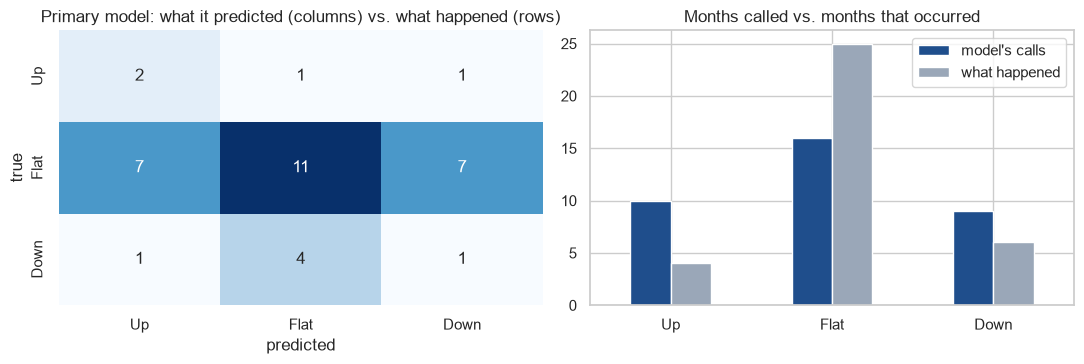

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.heatmap(confusion(predictions["y_true"], predictions["LOGISTIC (primary)"]), annot=True, fmt="d",
            cbar=False, cmap="Blues", ax=axes[0])
axes[0].set_title("Primary model: what it predicted (columns) vs. what happened (rows)")
calls = pd.DataFrame({"model's calls": predictions["LOGISTIC (primary)"].value_counts().reindex(CLASSES),
                      "what happened": predictions["y_true"].value_counts().reindex(CLASSES)})
calls.plot.bar(ax=axes[1], color=["#1F4E8C", "#9AA7B8"], rot=0)
axes[1].set_title("Months called vs. months that occurred")
plt.tight_layout()
plt.show()

**Reading it.**

- The primary model's balanced accuracy is **0.369**, below both persistence (0.406) and the seasonal rule (0.419), and inside the range luck produces: about a quarter of random guessing runs score at least as well.
- It catches **1 of 6 Down months** (the same as persistence) and **2 of 4 Up months**, but it gets there by calling moves constantly: **10 Up calls and 9 Down calls, against 4 and 6 that really happened**. Only 44% of the genuinely Flat months were called Flat. That is the cost of balanced class weights: it chases the rare classes and raises many false alarms.
- Plain accuracy is only **40%**, versus 71% for always-Flat.

## 2. How sure can we be? Intervals and paired comparisons

In [5]:
t = bootstrap_scores(predictions["y_true"], predictions["LOGISTIC (primary)"], n_boot=2000, seed=0)
t.loc[["accuracy", "balanced_accuracy", "macro_f1", "recall_down", "recall_up"], ["point", "lo", "hi"]].round(3)

,point,lo,hi
accuracy,0.400,0.257,0.571
balanced_accuracy,0.369,0.154,0.602
macro_f1,0.319,0.171,0.474
recall_down,0.167,0.000,0.600
recall_up,0.500,0.000,1.000


In [6]:
rows = []
for baseline in ("persistence", "seasonal", "always-majority"):
    for metric in ("balanced_accuracy", "recall_down", "macro_f1"):
        d = bootstrap_difference(predictions["y_true"], predictions["LOGISTIC (primary)"], predictions[baseline],
                                 metric=metric, n_boot=2000, seed=0)
        rows.append({"primary minus": baseline, "metric": metric, "difference": d["point"],
                     "95% low": d["lo"], "95% high": d["hi"], "share primary beats": d["share_positive"]})
pd.DataFrame(rows).round(3).set_index(["primary minus", "metric"])

difference  95% low  95% high  share primary beats
primary minus   metric                                                               
persistence     balanced_accuracy      -0.037   -0.431     0.304                0.410
                recall_down             0.000   -0.500     0.500                0.352
                macro_f1               -0.087   -0.364     0.153                0.266
seasonal        balanced_accuracy      -0.050   -0.187     0.151                0.240
                recall_down             0.000    0.000     0.000                0.000
                macro_f1               -0.110   -0.254     0.043                0.085
always-majority balanced_accuracy       0.036   -0.188     0.269                0.578
                recall_down             0.167    0.000     0.600                0.645
                macro_f1                0.041   -0.118     0.202                0.615

In [7]:
for baseline in ("persistence", "seasonal"):
    for label, cls in (("3-class", None), ("Down vs. rest", "Down")):
        r = mcnemar_exact(predictions["y_true"], predictions["LOGISTIC (primary)"], predictions[baseline], positive_class=cls)
        print(f"McNemar, primary vs {baseline:11s} ({label:13s}): only primary right = {r['a_only_correct']:2d}, "
              f"only {baseline} right = {r['b_only_correct']:2d}, p = {r['p_value']:.3f}")

McNemar, primary vs persistence (3-class      ): only primary right =  5, only persistence right = 13, p = 0.096
McNemar, primary vs persistence (Down vs. rest): only primary right =  4, only persistence right =  7, p = 0.549
McNemar, primary vs seasonal    (3-class      ): only primary right =  1, only seasonal right = 10, p = 0.012
McNemar, primary vs seasonal    (Down vs. rest): only primary right =  0, only seasonal right =  6, p = 0.031


**Reading it.** The intervals are wide (balanced accuracy 0.37, roughly 0.15 to 0.60), and every paired difference against persistence and always-majority includes zero or only just touches it. The one test that stands out goes the wrong way: on overall correctness the **seasonal rule beat the model** (it was right on 10 months where the model was wrong, the model on 1). So at this sample size the model is, if anything, worse than a calendar rule, never better. With several comparisons run, treat that p-value as suggestive.

## 3. Overfitting check: training months versus test months

If a model has truly learned something, it should do about as well on new months as on the months it trained on. A large gap means it memorized.

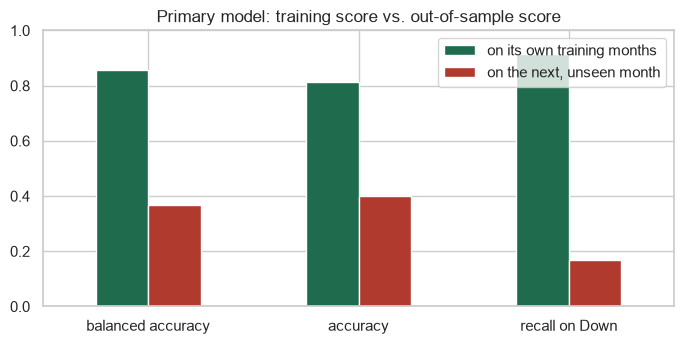

,on its own training months,"on the next, unseen month"
balanced accuracy,0.857,0.369
accuracy,0.812,0.400
recall on Down,0.915,0.167


In [8]:
insample = in_sample_scores(ready, make_logistic_regression, min_train=DEFAULT_MIN_TRAIN)
oos = scores.loc["LOGISTIC (primary)"]
gap = pd.DataFrame({
    "on its own training months": [insample["train_balanced_accuracy"].mean(), insample["train_accuracy"].mean(), insample["train_recall_down"].mean()],
    "on the next, unseen month": [oos["balanced_accuracy"], oos["accuracy"], oos["recall_down"]],
}, index=["balanced accuracy", "accuracy", "recall on Down"])

fig, ax = plt.subplots(figsize=(7, 3.6))
gap.plot.bar(ax=ax, color=["#1F6B4D", "#B03A2E"], rot=0)
ax.set_ylim(0, 1)
ax.set_title("Primary model: training score vs. out-of-sample score")
plt.tight_layout()
plt.show()
gap.round(3)

**Reading it.** On its own training months the model reaches about **0.86 balanced accuracy and 92% recall on Down**. On the next unseen month it manages **0.37 and 17%**. That gap is textbook overfitting, and it happened even with strong regularization. With 22 features and 24 to 58 training rows, a model can find a pattern in almost any set of months. It just doesn't carry over.

## 4. Exploratory sensitivity (reported in full, no winner picked)

Does a different setting rescue it? These are the same walk-forward runs with other values of `C` and class weights, and with only some groups of features. **Every variant is shown.** These were not pre-specified, so none of them is a finding.

In [9]:
rows = []
for C in (0.01, 0.1, 1.0, 10.0):
    for weights in ("balanced", None):
        pred = compare_models(ready, {"m": (lambda C=C, w=weights: make_logistic_regression(C=C, class_weight=w))},
                              min_train=DEFAULT_MIN_TRAIN)
        s = score_table(pred).loc["m"]
        rows.append({"variant": f"C={C}, weights={weights}", "accuracy": s["accuracy"],
                     "balanced_accuracy": s["balanced_accuracy"], "recall_down": s["recall_down"], "recall_up": s["recall_up"]})
variants = pd.DataFrame(rows).set_index("variant")
variants.round(3)

,accuracy,balanced_accuracy,recall_down,recall_up
variant,,,,
"C=0.01, weights=balanced",0.457,0.466,0.167,0.75
"C=0.01, weights=None",0.714,0.333,0.000,0.00
"C=0.1, weights=balanced",0.400,0.369,0.167,0.50
"C=0.1, weights=None",0.657,0.377,0.000,0.25
"C=1.0, weights=balanced",0.400,0.299,0.167,0.25
"C=1.0, weights=None",0.571,0.379,0.167,0.25
"C=10.0, weights=balanced",0.457,0.326,0.167,0.25
"C=10.0, weights=None",0.457,0.326,0.167,0.25


In [10]:
subsets = {"all 22 features": FEATURES,
           "share history only": [c for c in FEATURE_GROUPS["share_history"] if c in FEATURES],
           "calendar only": [c for c in FEATURE_GROUPS["calendar"] if c in FEATURES],
           "volume only": [c for c in FEATURE_GROUPS["volume"] if c in FEATURES],
           "calendar + share history": [c for g in ("calendar", "share_history") for c in FEATURE_GROUPS[g] if c in FEATURES]}
rows = []
for name, cs in subsets.items():
    pred = compare_models(ready[[TARGET] + cs], {"m": make_logistic_regression}, min_train=DEFAULT_MIN_TRAIN)
    s = score_table(pred).loc["m"]
    rows.append({"features": name, "count": len(cs), "accuracy": s["accuracy"], "balanced_accuracy": s["balanced_accuracy"],
                 "recall_down": s["recall_down"], "recall_up": s["recall_up"]})
pd.DataFrame(rows).set_index("features").round(3)

,count,accuracy,balanced_accuracy,recall_down,recall_up
features,,,,,
all 22 features,22,0.400,0.369,0.167,0.50
share history only,10,0.371,0.328,0.333,0.25
calendar only,5,0.429,0.424,0.333,0.50
volume only,6,0.229,0.317,0.000,0.75
calendar + share history,15,0.400,0.341,0.333,0.25


**Reading it, carefully.**

- One variant (`C=0.01`, balanced) reaches balanced accuracy of **0.47**, a hair above the chance ceiling of 0.46. That is **not a finding**. It is one of about a dozen variants tried (8 settings plus 4 other feature sets), and the chance that at least one of a dozen tries clears a 95th-percentile line by luck is roughly one in two. Picking it now would be exactly the fit-the-test-set mistake the pre-specification was meant to prevent.
- **Fewer features does not reliably help.** Share history only (0.33), volume only (0.32) and calendar plus share history (0.34) all score slightly *below* the full model's 0.37. Only the 5 calendar features alone score higher (0.42, with recall on Down of 2 of 6). That is one subset out of four, so it is not a finding either, though it is consistent with the overfitting diagnosis: more features gave the model more ways to memorize.
- However the variants are cut, the best of them sit at or just inside the edge of the chance band.

## 5. What does it lean on? (descriptive only)

The model trained on all 59 months, in-sample. This is a sanity check on the signs, not evidence of predictive power.

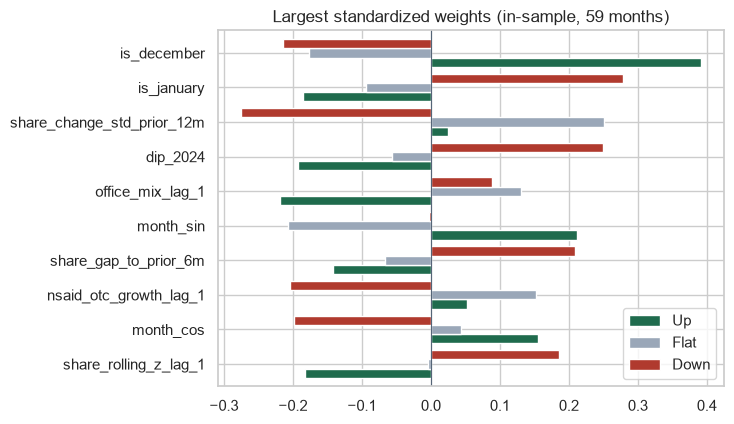

In [11]:
final = make_logistic_regression().fit(ready[FEATURES], ready[TARGET])
regression = final.steps[1][1]
coef = pd.DataFrame(regression.coef_.T, index=FEATURES, columns=list(regression.classes_))
top = coef.reindex(coef.abs().max(axis=1).sort_values(ascending=False).index).head(10)[["Up", "Flat", "Down"]]
fig, ax = plt.subplots(figsize=(7.5, 4.4))
top.iloc[::-1].plot.barh(ax=ax, color=["#1F6B4D", "#9AA7B8", "#B03A2E"], width=0.8)
ax.axvline(0, color="#556578", lw=0.8)
ax.set_title("Largest standardized weights (in-sample, 59 months)")
plt.tight_layout()
plt.show()

The signs agree with the EDA: `is_december` pushes toward Up and `is_january` toward Down (the seasonality found earlier). That is reassuring about the features and the pipeline. It does not make the model predictive: the weights are small, and the overfitting check above shows they don't hold up on unseen months.

## Takeaways

| (35 test months: 25 Flat, 6 Down, 4 Up) | Always-majority | Persistence | Seasonal | **Logistic (primary)** |
|---|---|---|---|---|
| Accuracy | 71.4% | 62.9% | 65.7% | 40.0% |
| Balanced accuracy | 0.333 | 0.406 | 0.419 | 0.369 |
| Recall on Down | 0 of 6 | 1 of 6 | 1 of 6 | 1 of 6 |
| Recall on Up | 0 of 4 | 1 of 4 | 1 of 4 | 2 of 4 |

1. **The pre-specified logistic regression does not beat the baselines, and does not beat chance.** Its balanced accuracy of 0.37 is inside the range random guessing produces.
2. **It overfits:** about 0.86 balanced accuracy on the months it trained on, 0.37 on unseen months, even with strong regularization.
3. **No exploratory variant is a finding.** The one that clears the chance ceiling does so barely, and it is one of about a dozen tries.
4. **This fits the earlier evidence.** The label measures a *surprise* relative to recent volatility, and 59 months (16 of them Up or Down) is too little to learn what predicts surprises. The simple baselines were already indistinguishable from chance.

**What this means for the project.** The pipeline, the features and the test harness are sound; the finding is that this particular label is not predictable from these features at this sample size. Reasonable next steps, none of them run yet: reframe the question (for example "Down versus not Down", or predict the size of the change), try a much simpler model with only the calendar features chosen in advance, get more history, or report the null result as the project's finding. The harness makes any of these a fair test.